## Setup and Imports

This section imports required libraries and defines any global configurations used throughout the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

## Setup and Imports

This section imports required libraries and defines any global configurations used throughout the analysis.

In [2]:
import os

data_path = "/Users/paigeblackstone/Library/Mobile Documents/com~apple~CloudDocs/Formula 1 Fun"

files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

tables = {}
for f in files:
    name = f.replace(".csv", "")
    tables[name] = pd.read_csv(os.path.join(data_path, f))

tables.keys()

dict_keys(['circuits', 'status', 'lap_times', 'sprint_results', 'drivers', 'races', 'constructors', 'constructor_standings', 'qualifying', 'driver_standings', 'constructor_results', 'pit_stops', 'seasons', 'results'])

## Build Master Dataset

This section merges core tables into a single dataset centered on race results.

In [3]:
results = tables["results"].copy()
races = tables["races"].copy()
drivers = tables["drivers"].copy()
constructors = tables["constructors"].copy()
circuits = tables["circuits"].copy()
status = tables["status"].copy()

# Clean duplicate columns
for df in [races, drivers, constructors, circuits]:
    if "url" in df.columns:
        df.drop(columns=["url"], inplace=True)

races["date"] = pd.to_datetime(races["date"])

master = (
    results
    .merge(races, on="raceId", how="left")
    .merge(drivers, on="driverId", how="left")
    .merge(constructors, on="constructorId", how="left")
    .merge(circuits, on="circuitId", how="left")
    .merge(status, on="statusId", how="left")
)

master.shape

(26759, 52)

## Create Target Variable

This section defines the modeling target based on whether a driver scored points in a race.

In [4]:
master["target_points"] = (master["points"] > 0).astype(int)
master["target_points"].value_counts()

target_points
0    18589
1     8170
Name: count, dtype: int64

## Data Cleaning

This section standardizes key columns and prepares variables for modeling.

In [5]:
# Clean grid
master["grid_clean"] = pd.to_numeric(master["grid"], errors="coerce")
master.loc[master["grid_clean"] == 0, "grid_clean"] = np.nan

## Feature Engineering

This section creates rolling performance and reliability features using historical race data.

In [6]:
#driver performance
master = master.sort_values(["driverId", "date"])

master["driver_avg_finish_last5"] = (
    master.groupby("driverId")["positionOrder"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

master["driver_points_last5"] = (
    master.groupby("driverId")["points"]
    .transform(lambda x: x.shift(1).rolling(5).sum())
)

In [7]:
#constructor performance
master = master.sort_values(["constructorId", "date"])

master["constructor_points_last5"] = (
    master.groupby("constructorId")["points"]
    .transform(lambda x: x.shift(1).rolling(5).sum())
)

In [8]:
#reliability/DNFs
finish_like = [
    "Finished",
    "+1 Lap", "+2 Laps", "+3 Laps", "+4 Laps",
    "+5 Laps", "+6 Laps", "+7 Laps", "+8 Laps", "+9 Laps"
]

master["is_dnf"] = (~master["status"].isin(finish_like)).astype(int)

# Driver DNF
tmp_driver = master.sort_values(["driverId", "date"])
master["driver_dnf_rate_last5"] = (
    tmp_driver.groupby("driverId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

# Constructor DNF
tmp_constructor = master.sort_values(["constructorId", "date"])
master["constructor_dnf_rate_last5"] = (
    tmp_constructor.groupby("constructorId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

## Modeling Dataset

This section selects relevant features and removes missing values to create the final modeling dataset.

In [10]:
master = master.drop(
    columns=[c for c in master.columns if c in ["qualifying_position", "position_x", "position_y"]],
    errors="ignore"
)

In [11]:
qualifying = tables["qualifying"].copy()

qualifying = qualifying.rename(columns={"position": "qualifying_position"})

master = (
    master
    .merge(
        qualifying[["raceId", "driverId", "qualifying_position"]],
        on=["raceId", "driverId"],
        how="left",
        validate="m:1"
    )
)

master.shape

(26759, 61)

In [12]:
[c for c in master.columns if "position" in c.lower()]

['position', 'positionText', 'positionOrder', 'qualifying_position']

In [13]:
[c for c in master.columns if "name" in c.lower()]

['name_x', 'forename', 'surname', 'name_y', 'name']

In [14]:
features = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "constructor_points_last5",
    "driver_dnf_rate_last5",
    "constructor_dnf_rate_last5",
    "year"
]

model_df = master[["target_points"] + features].dropna().copy()
model_df.shape

(9729, 8)

## Train/Test Split

This section splits the dataset into training and testing sets based on time.

In [15]:
train = model_df[(model_df["year"] >= 2014) & (model_df["year"] <= 2021)]
test = model_df[model_df["year"] >= 2022]

X_train = train[features]
y_train = train["target_points"]

X_test = test[features]
y_test = test["target_points"]

## Logistic Regression Model

This section trains a logistic regression model and evaluates performance.

In [19]:
#logistic regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

preds = model_lr.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, preds)

roc_auc_lr

0.8707170585219366

## XGBoost Model

This section trains a gradient boosting model and evaluates performance.

In [20]:
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model_xgb.fit(X_train, y_train)

preds_xgb = model_xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, preds_xgb)

roc_auc_xgb

0.8521326204253032

## Model Explainability (SHAP)

This section computes SHAP values to analyze feature contributions.

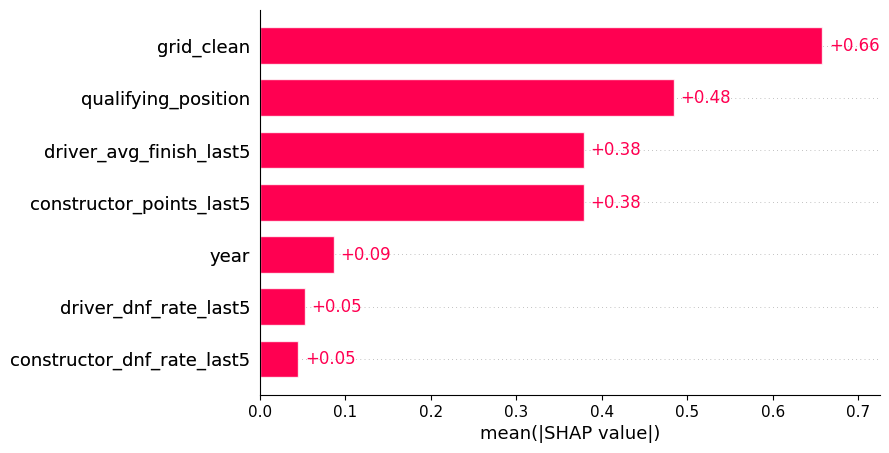

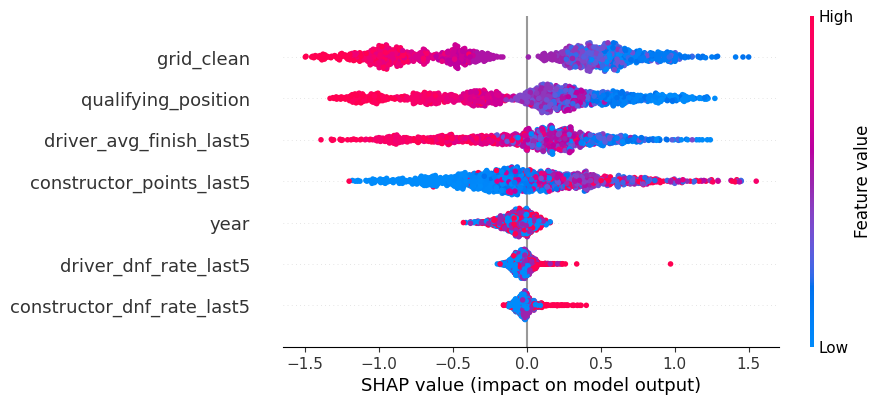

In [17]:
import shap

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

## Visualization

This section generates charts to visualize relationships between features and outcomes.

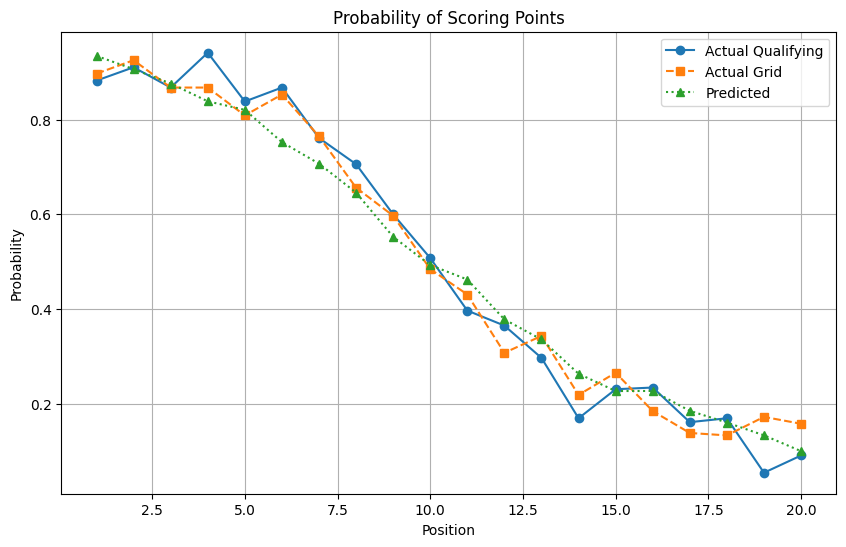

In [21]:
test_plot = test.copy()
test_plot["pred_prob"] = model_lr.predict_proba(X_test)[:, 1]

qual_actual = test_plot.groupby("qualifying_position")["target_points"].mean()
grid_actual = test_plot.groupby("grid_clean")["target_points"].mean()
qual_pred = test_plot.groupby("qualifying_position")["pred_prob"].mean()

plt.figure(figsize=(10,6))

plt.plot(qual_actual.index, qual_actual.values, marker="o", label="Actual Qualifying")
plt.plot(grid_actual.index, grid_actual.values, marker="s", linestyle="--", label="Actual Grid")
plt.plot(qual_pred.index, qual_pred.values, marker="^", linestyle=":", label="Predicted")

plt.title("Probability of Scoring Points")
plt.xlabel("Position")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

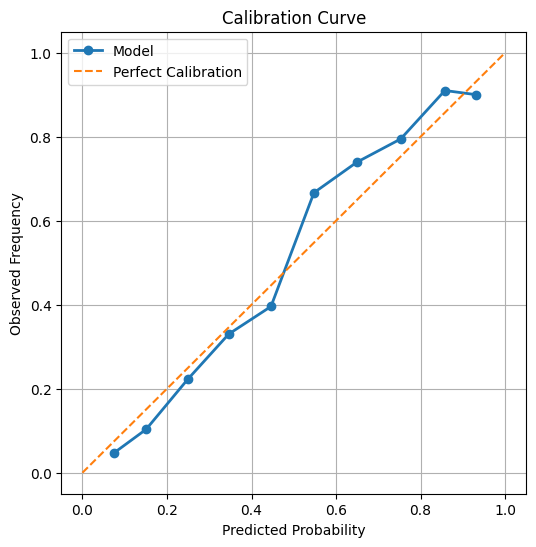

In [23]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    model_lr.predict_proba(X_test)[:, 1],
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect Calibration")

plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

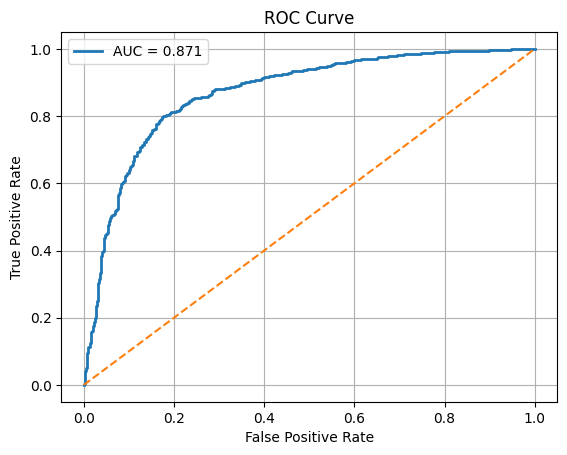

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, preds)

plt.figure()
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_lr:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

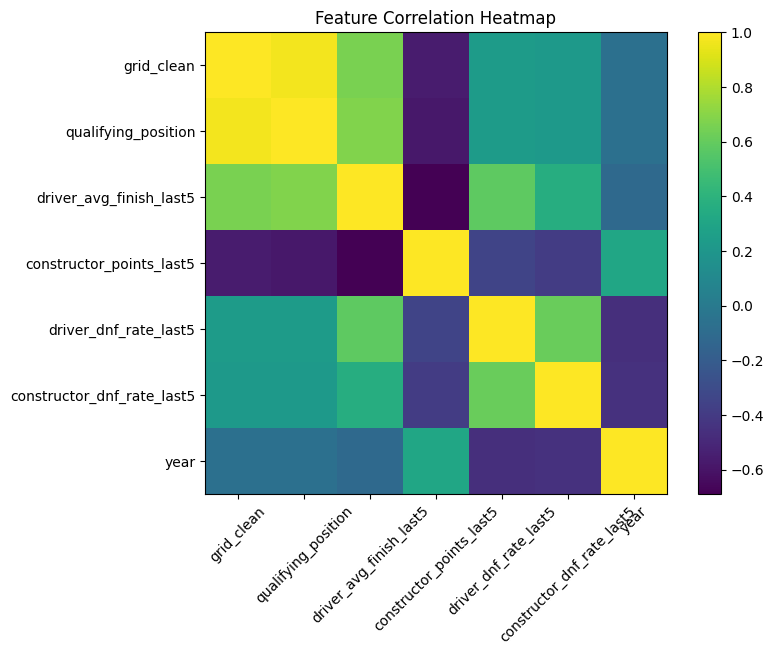

In [25]:
corr = model_df.drop(columns=["target_points"]).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

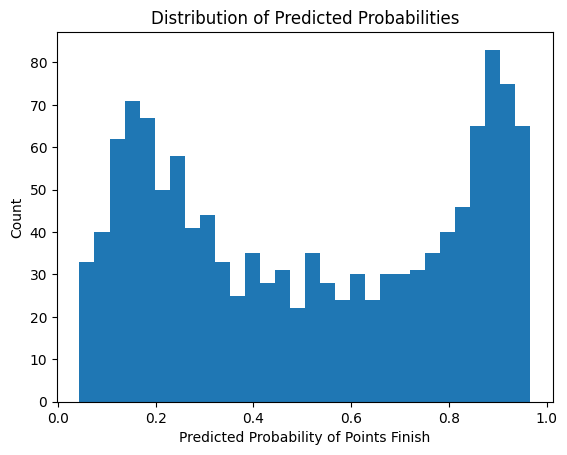

In [26]:
plt.figure()

plt.hist(
    model_lr.predict_proba(X_test)[:, 1],
    bins=30
)

plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability of Points Finish")
plt.ylabel("Count")
plt.show()

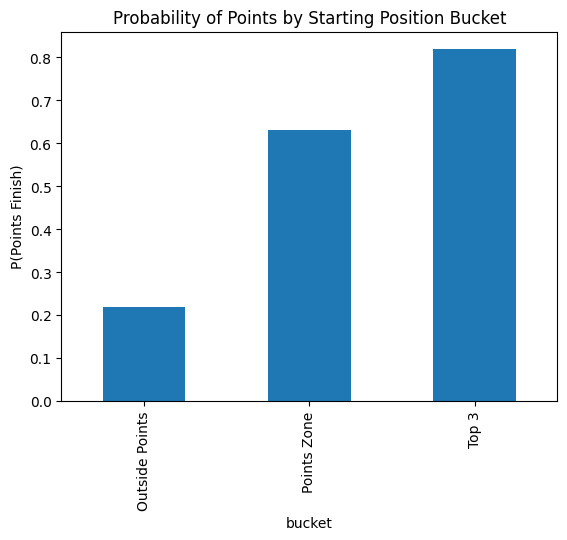

In [27]:
def bucket_position(x):
    if x <= 3:
        return "Top 3"
    elif x <= 10:
        return "Points Zone"
    else:
        return "Outside Points"

bucket_plot = (
    master.assign(bucket=master["qualifying_position"].apply(bucket_position))
    .groupby("bucket")["target_points"]
    .mean()
)

bucket_plot.plot(kind="bar")
plt.title("Probability of Points by Starting Position Bucket")
plt.ylabel("P(Points Finish)")
plt.show()

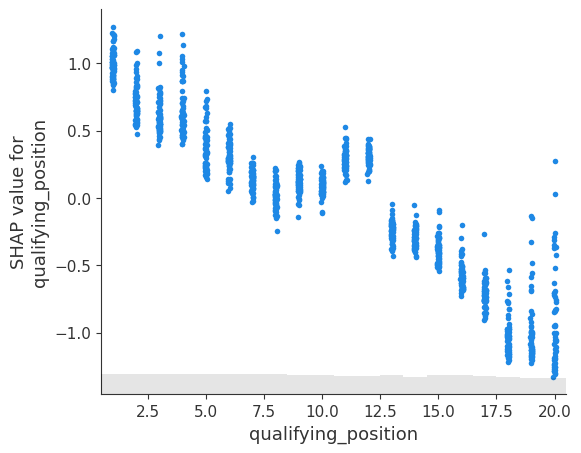

In [28]:
shap.plots.scatter(shap_values[:, "qualifying_position"])

This project set out to understand how predictable Formula 1 race outcomes are—specifically, what factors most influence whether a driver scores points. To answer this, we combined multiple historical F1 datasets into a unified race-level table and engineered time-aware features capturing starting position, recent driver and constructor performance, and reliability (DNF rates). We then trained both logistic regression and XGBoost models using a time-based split to reflect real-world prediction. The results showed that race outcomes are highly predictable (ROC-AUC ~0.87), with starting position—especially qualifying—being the dominant driver, while recent performance adds incremental value and reliability plays a smaller, secondary role.

---

To ensure data quality, we performed several validation and cleaning steps prior to modeling. This included standardizing key variables (such as converting grid positions to numeric and handling invalid values), resolving duplicate or conflicting columns introduced during joins, and verifying join integrity across tables using primary keys (e.g., raceId, driverId, constructorId). We also carefully constructed time-aware features using lagged rolling windows to prevent data leakage, ensuring that only information available prior to each race was used in feature generation. Missing values introduced by rolling calculations were handled systematically by filtering to complete cases in the modeling dataset, resulting in a clean and consistent analytical base.

---

Model performance was evaluated using a time-based train/test split to reflect real-world predictive conditions, with ROC-AUC as the primary metric. Across multiple model specifications, including logistic regression and XGBoost, performance remained consistently high (AUC ~0.85–0.87), indicating strong predictive signal. In addition to accuracy, we assessed model reliability through calibration analysis and lift by prediction decile, confirming that predicted probabilities aligned well with observed outcomes and that the model effectively ranked drivers by likelihood of scoring points. Together, these evaluations demonstrate that the model is not only accurate but also well-calibrated and reliable for probabilistic interpretation.

---